In [431]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp  

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [460]:
P=4
alpha=0.01
mu0=4*np.pi*1e-7
vol=310.7127127309003
mur= 60.88934374015058
sigma=3295075.7414894877
N=3000
NPOD=50

In [461]:
# Select directory
#directory="Results/OCC_Gun_modelv2_nonsym_StainSt/al_0.01_mu_1,100_sig_1.45e6,4.5e6/1e-1-1e10_"+str(N)+"_el_18002_ord_"+str(P)+"_POD_"+str(NPOD)+"_1e-6"
# New geometry with bar on reciever not barrel, prisms on barrel only
#directory="Results/OCC_Gun_modelv3_nonsym_StainSt/al_0.01_mu_1,100_sig_1.45e6,4.5e6/1e-1-1e10_"+str(N)+"_el_18948_ord_"+str(P)+"_POD_50_1e-6"
# New geometry with bar on reciever not barrel, prisms on all
directory="Results/OCC_Gun_modelv3_nonsym_StainSt/al_0.01_mu_1,100_sig_1.45e6,4.5e6/1e-1-1e10_"+str(N)+"_el_21176_ord_"+str(P)+"_POD_50_1e-6"
           #Results/OCC_Gun_modelv3_nonsym_StainSt/al_0.01_mu_1,100_sig_1.45e6,4.5e6/1e-1-1e10_3000_el_21176_ord_4_POD_50_1e-6



# Note this geometry is different to the OCC_Gun_modelv2_nonsym_StainSt geometry. Instead of adding a block to the barrel we add a block to the reciever.
# There appears to be an issue with the original geometry (due to the added block - without it is fine). 
# It appear this geometry is not being used correctly with the main barrel. Many tests have been done without a successful conclusion
# Hence new geoemtry.

ck=np.genfromtxt(directory+'/Data/Amplitudes.csv', delimiter=',')
xi=np.genfromtxt(directory+'/Data/Modes.csv', delimiter=',')
Omega=np.genfromtxt(directory+'/Data/Frequencies.csv', delimiter=',')
time=np.genfromtxt(directory+'/Data/Time.csv', delimiter=',')
Sgn_step= np.genfromtxt(directory+'/Data/Sgn_step.csv', delimiter=',')
Sgn_impulse= np.genfromtxt(directory+'/Data/Sgn_impulse.csv', delimiter=',')
TensorArray= np.genfromtxt(directory+'/Data/Tensors.csv', delimiter=',', dtype=complex)
Eigenvalues=np.genfromtxt(directory+'/Data/Eigenvalues.csv', delimiter=',', dtype=complex)
Minf= np.genfromtxt(directory+'/Data/Minf.csv', delimiter=',')
N0= np.genfromtxt(directory+'/Data/N0.csv', delimiter=',')


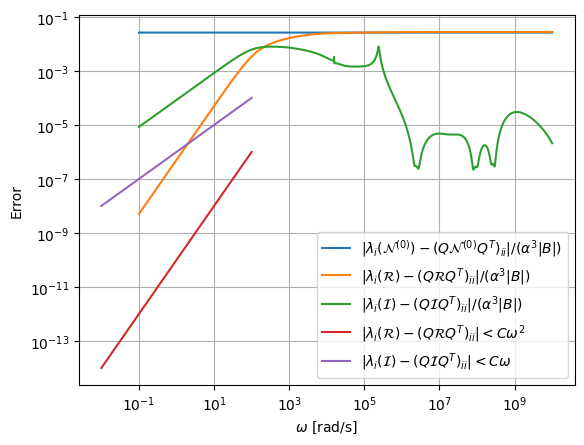

In [462]:
uinf,Qinf=np.linalg.eig(Minf)
myord=np.argsort(np.abs(uinf))
uinf=uinf[myord]
Qinf=Qinf[:,myord]

uN0,QN0=np.linalg.eig(N0)
myord=np.argsort(np.abs(uN0))
uN0=uN0[myord]
QN0=QN0[:,myord]
QN0=QN0[myord,:]

utest=np.transpose(Qinf)@np.real(N0)@Qinf
myord=np.argsort(np.diag(np.abs(utest)))
utest=utest[:,myord]
utest=utest[myord,:]

errorsN0=np.linalg.norm(uN0-np.diag(utest))*np.ones(len(Omega))
  

# Check the similarity of applying Qinf
errorsre=np.zeros(len(Omega))
errorsim=np.zeros(len(Omega))

for n in range(len(Omega)):
    lamre=np.real(Eigenvalues[n])
    Ten=TensorArray[n,:]
    MPT=np.zeros((3,3),dtype=complex)
    MPT[0,0]=Ten[0]
    MPT[0,1]=Ten[1]
    MPT[0,2]=Ten[2]
    MPT[1,0]=Ten[3]
    MPT[1,1]=Ten[4]
    MPT[1,2]=Ten[5]
    MPT[2,0]=Ten[6]
    MPT[2,1]=Ten[7]
    MPT[2,2]=Ten[8]
    ure,Qre=np.linalg.eig(np.real(MPT-N0))
    myord=np.argsort(np.abs(ure))
    ure=ure[myord]
    #Qre=Qre[:,myord]
    uim,Qim=np.linalg.eig(np.imag(MPT))
    myord=np.argsort(uim)
    uim=uim[myord]
    #Qim=Qim[:,myord]
    # Compare
    #print(MPT)
    utest=np.transpose(Qinf)@np.real(MPT-N0)@Qinf
    myord=np.argsort(np.diag(np.abs(utest)))
    utest=utest[:,myord]
    utest=utest[myord,:]
    
    #errorsre[n]=np.linalg.norm(np.diag(ure)-np.diag(np.diag(utest)))
    errorsre[n]=np.linalg.norm(ure-np.diag(utest))
    
    #print(errorsre[n]/alpha**3/vol,ure,np.diag(utest))
    
    utest=np.transpose(Qinf)@np.imag(MPT)@Qinf
    myord=np.argsort(np.diag(utest))
    utest=utest[:,myord]
    utest=utest[myord,:]
    
    errorsim[n]=np.linalg.norm(uim-np.diag(utest))
    #print(errorsim[n]/alpha**3/vol,uim,np.diag(utest))
    
plt.figure()
plt.loglog(Omega,errorsN0/alpha**3/vol,label=r"$| \lambda_i({\cal N}^{(0)})-(Q{\cal N}^{(0)} Q^T)_{ii}|/ (\alpha^3|B|)$")
plt.loglog(Omega,errorsre/alpha**3/vol,label=r"$| \lambda_i({\cal R})-(Q{\cal R} Q^T)_{ii}|/ (\alpha^3|B|)$")
plt.loglog(Omega,errorsim/alpha**3/vol,label=r"$| \lambda_i({\cal I})-(Q{\cal I} Q^T)_{ii}|/ (\alpha^3|B|)$")


#log error = 2*log omega +c
#c=log 1e-17-(log 1e-2)*2
c1=10**(np.log10(1e-14)-2*np.log10(1e-2))
line1=np.array(([[1e-2, 1e-14],[1e2, 10**(np.log10(1e2)*2+np.log10(c1) )]]))
plt.plot(line1[:,0],line1[:,1],label=r"$| \lambda_i({\cal R})-(Q{\cal R} Q^T)_{ii}|< C \omega^2$")
c2=10**(np.log10(1e-8)-np.log10(1e-2))
line2=np.array(([[1e-2, 1e-8],[1e2, 10**(np.log10(1e2)+np.log10(c2))]]))
plt.plot(line2[:,0],line2[:,1],label=r"$| \lambda_i({\cal I})-(Q{\cal I} Q^T)_{ii}|<  C \omega$")



plt.legend()
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"Error")
plt.grid()
plt.savefig("my_plots/gun/abserrplot_gun.pdf")

3000
3000
3000


/tmp/user/10925/ipykernel_3118110/3141869765.py:10: RuntimeWarning: divide by zero encountered in log10
  plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))


<Figure size 640x480 with 0 Axes>

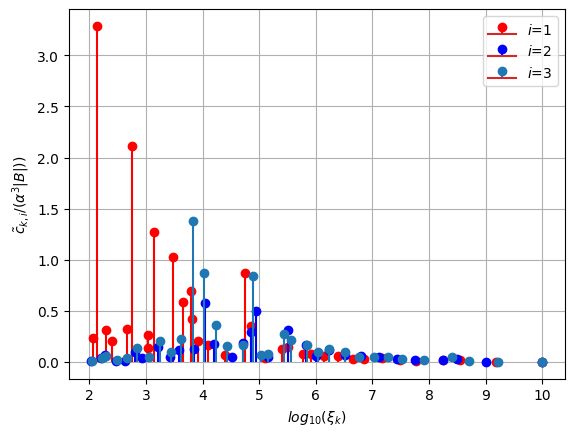

In [463]:
# Compare the modes and amplitudes
plt.figure()
col=['r','b','x']
plt.figure()
for i in range(3):
    nfound=len(xi[:,i])
    ckp=ck[0:nfound,i]
    xip=xi[0:nfound,i]
    print(nfound)
    plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))

    plt.xlabel(r'$log_{10}(\xi_{k})$')
    plt.ylabel(r'$\tilde{c}_{k,i}/ (\alpha^3 |B|))$')

plt.grid()
plt.legend()
plt.savefig("my_plots/gun/amp_modes_ev3000_gun.pdf")



/tmp/user/10925/ipykernel_3118110/3259287778.py:10: RuntimeWarning: divide by zero encountered in divide
  DRSF+=ckp[n]/(1+1j*Omega/xip[n])
/tmp/user/10925/ipykernel_3118110/3259287778.py:10: RuntimeWarning: invalid value encountered in divide
  DRSF+=ckp[n]/(1+1j*Omega/xip[n])


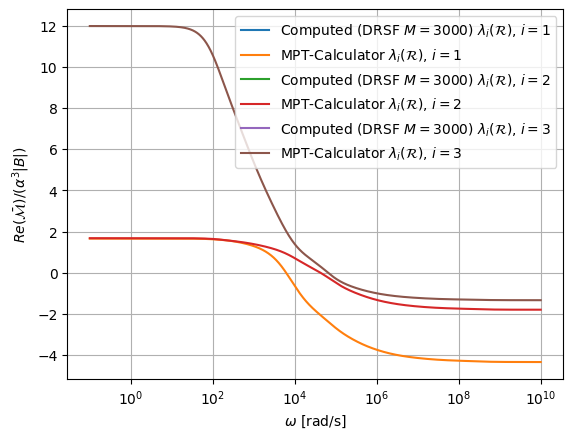

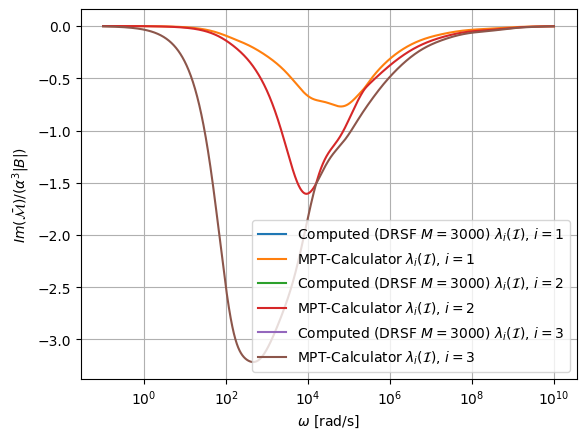

[[-1.33511234e+00 -1.13628951e-03 -1.78077012e-02]
 [-1.13628951e-03 -4.33963610e+00  3.43724023e-04]
 [-1.78077012e-02  3.43724023e-04 -1.79550093e+00]]


In [464]:
N=len(Omega)
for i in range(3):
    #DRSF=MPTinf_ob[i,i]*np.ones((N),dtype=complex)
    nfound=len(xi[:,0])
    ckp=ck[0:nfound,i]
    xip=xi[:,i]
    # We need to use e.values of MPTinf and take account of ordering this is now done in getimpulse_step
    DRSF=(ckp[0])*np.ones((N),dtype=complex)
    for n in range(1,nfound):
        DRSF+=ckp[n]/(1+1j*Omega/xip[n])
    plt.figure(1)
    plt.semilogx(Omega,np.real(DRSF)/(alpha**3*vol),label=r"Computed (DRSF $M=3000$) $\lambda_i({\cal R})$, $i=$"+str(i+1))
    plt.semilogx(Omega,np.real(Eigenvalues[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i({\cal R})$, $i=$"+str(i+1))
    
    plt.figure(2)
    plt.semilogx(Omega,np.imag(DRSF)/(alpha**3*vol),label=r"Computed (DRSF $M=3000$) $\lambda_i({\cal I})$, $i=$"+str(i+1))
    plt.semilogx(Omega,-np.imag(Eigenvalues[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i({\cal I})$, $i=$"+str(i+1))
                 
  
plt.figure(1)

plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"$Re(\bar{\cal M})/(\alpha^3|B|)$")
plt.grid()
plt.legend()
plt.savefig("my_plots/gun/computed_realmpt_M3000_gun.pdf")

plt.figure(2)
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"$Im(\bar{\cal M})/(\alpha^3|B|)$")
plt.legend()
plt.grid()
plt.savefig("my_plots/gun/computed_imagmpt_M3000_gun.pdf")
plt.show()

print(Minf/(alpha**3*vol))

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/user/10925/ipykernel_3118110/2436527900.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.semilogx(time,Sgn_step[:,i]/scale,label="Numerical Gun step, $\lambda_i$, $i$="+str(i+1))


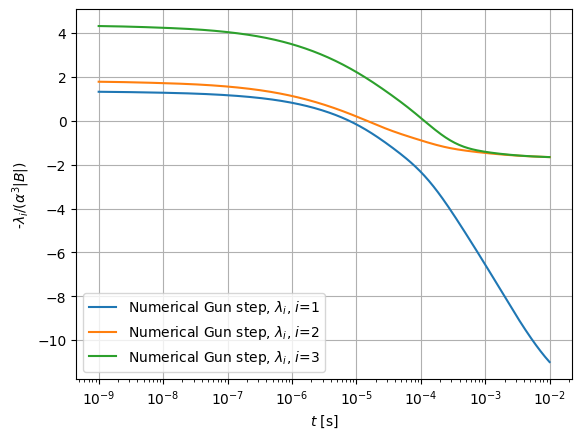

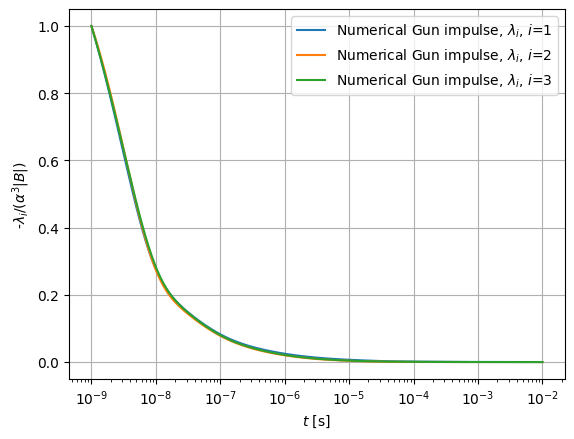

In [465]:
# Important note this is -lambda response as it tends to -1 for large time (ie -lambda(N0)(2*pi*alpha^3))
plt.figure(1)
scale=vol*alpha**3
for i in range(3):
    #scale=Sgn_step[0,i]
    plt.semilogx(time,Sgn_step[:,i]/scale,label="Numerical Gun step, $\lambda_i$, $i$="+str(i+1))
plt.legend()
plt.grid()
plt.xlabel(r"$t$ [s]")
plt.ylabel(r"-$\lambda_i/(\alpha^3|B|)$")
plt.savefig("my_plots/gun/gun_step_semilog.pdf")




plt.figure(2)
for i in range(3):
    scale=Sgn_impulse[0,i]
    plt.semilogx(time,Sgn_impulse[:,i]/scale,label=r"Numerical Gun impulse, $\lambda_i$, $i$="+str(i+1))
    
plt.legend()
plt.grid()
plt.xlabel(r"$t$ [s]")
plt.ylabel(r"-$\lambda_i/(\alpha^3 |B|)$")
plt.savefig("my_plots/gun/gun_impulse_semilog.pdf")
plt.show()


In [466]:
"""from Functions.Core_Spectrum.getimpulse_step import *
"""

'from Functions.Core_Spectrum.getimpulse_step import *\n'

In [467]:
# remove scaling
"""TensorArrayn=TensorArray#/(2*np.pi*alpha**3)
Minfn = Minf #/(2*np.pi*alpha**3)

#Minfn=-1*np.eye(3)
xi_iter, ck_iter, Nfound_iter = PolesandAmp(Omega,np.conj(TensorArrayn),Minfn, Iterative_refine=False)
ck_iter=ck_iter#*(2*np.pi*alpha**3)"""

'TensorArrayn=TensorArray#/(2*np.pi*alpha**3)\nMinfn = Minf #/(2*np.pi*alpha**3)\n\n#Minfn=-1*np.eye(3)\nxi_iter, ck_iter, Nfound_iter = PolesandAmp(Omega,np.conj(TensorArrayn),Minfn, Iterative_refine=False)\nck_iter=ck_iter#*(2*np.pi*alpha**3)'

In [468]:
"""plt.figure()
col=['r','b','x']
plt.figure(1)
for i in range(3):
    nfound=len(xi_iter[:,i])
    ckp=ck_iter[0:nfound,i]
    xip=xi_iter[0:nfound,i]
    plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))
    plt.xlabel(r'$log_{10}(\xi_{k})$')
    plt.ylabel(r'$\tilde{c}_{k,i}/ (\alpha^3 |B| )$')

plt.grid()
#plt.xlim(4,12)
plt.legend()
#plt.savefig("my_plots/sphere_mpt/modes_amp_iter_refine_Nfreq_"+str(N)+"_p_"+str(P)+"_POD_50_1e-6.pdf")

plt.figure()
col=['r','b','x']
plt.figure()
for i in range(3):
    nfound=len(xi[:,i])
    ckp=ck[0:nfound,i]
    xip=xi[0:nfound,i]
    plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))
    plt.xlabel(r'$log_{10}(\xi_{k})$')
    plt.ylabel(r'$\tilde{c}_{k,i}/ (\alpha^3 |B| )$')
    

plt.grid()
#plt.xlim(4,12)
plt.legend()
#plt.savefig("my_plots/sphere_mpt/modes_amp_nnls_Nfreq_"+str(N)+"_p_"+str(P)+"_POD_"+str(NPOD)+"_1e-6.pdf")
plt.show()"""

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 270-271: truncated \xXX escape (1690172858.py, line 1)

In [469]:
# Find ellipsoid from N0

In [470]:
from equiv_ellip import *
EvN0,QN0=np.linalg.eig(N0)      
order=np.argsort(-EvN0)
print(order)
EvN0=EvN0[order]
LamPS=np.zeros((3,3),dtype=float)
for i in range(3):
    LamPS[i,i]=EvN0[i]
print(LamPS)

[0 2 1]
[[0.00372338 0.         0.        ]
 [0.         0.00052134 0.        ]
 [0.         0.         0.00051544]]


In [471]:
vol_ellip=(1+3/(mur-1))/(alpha**3*np.trace(np.linalg.inv(LamPS)))
print(vol,vol_ellip)
Hill=np.linalg.inv(LamPS)*alpha**3*vol_ellip-np.eye(3)/(mur-1)
print("Hill Tensor")
print(Hill)
if np.abs(np.trace(Hill)-1.) > 1e-12:
    print("Trace of Hill tensor is not 1",np.trace(Hill))
    old_trace=np.trace(Hill)
    Hill=Hill/old_trace
    print(Hill)

tol=None
ellip=find_ellipsoid(Hill,vol_ellip,tol)
print("Computed vol",4/3*np.pi*ellip[0]*ellip[1]*ellip[2])
PS,Hill=PStensor(ellip[0],ellip[1],ellip[2],alpha,mur,vol_ellip)
print("Tolerance=",tol,"Error in PS",np.linalg.norm(PS-LamPS)/np.linalg.norm(LamPS))

310.7127127309003 254.4582972248589
Hill Tensor
[[0.05164325 0.         0.        ]
 [0.         0.47138559 0.        ]
 [0.         0.         0.47697116]]
solution to min problem [0.18801497 0.19016092]
Ellipsoid found is  [11.93268296  2.26913001  2.243523  ]
Computed vol 254.45829722485888
0.05164324963615853
PS Tensor
[[0.00372338 0.         0.        ]
 [0.         0.00052134 0.        ]
 [0.         0.         0.00051544]]
Hill Tensor
[[0.05164325 0.         0.        ]
 [0.         0.47138558 0.        ]
 [0.         0.         0.47697117]]
Tolerance= None Error in PS 5.1419677885782275e-09


/home/pdl11/Coding/MPT_calculator/July2026/MPT-Calculator/equiv_ellip.py:83: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  IC=quad(C,1,np.inf,args=(x1,x2))[0]


In [472]:
# Find ellipsoid from Minf

In [473]:
"""# try an approach using non-linear root finding with equality and in-equality constraints
# x[0] vol ellip
# x[1] exp(A)
# x[2] exp(B)
# x[3] exp(C)

print(Minf)
EvMinf,QMinf=np.linalg.eig(Minf)      
order=np.argsort(-EvMinf)
EvMinf=EvMinf[order]
LamPS=np.zeros((3,3),dtype=float)
for i in range(3):
    LamPS[i,i]=EvMinf[i]
print(LamPS)
from scipy.optimize import root
# Objective function

def obj(x):
    P =np.diag(np.array((x[1],x[2],x[3])))
    return np.linalg.norm( LamPS +alpha**3*x[0]*np.linalg.inv(np.eye(3)-P))

def myF(x):
    P =np.array((np.exp(x[1]),np.exp(x[2]),np.exp(x[3])))
    
    return np.array([np.exp(x[1])+np.exp(x[2])+np.exp(x[3])-1, 
            (LamPS[0,0]) +x[0]/(1-P[0]),
            (LamPS[1,1]) +x[0]/(1-P[1]),
            (LamPS[2,2]) +x[0]/(1-P[2])])   
def myjac(x):
    P =np.array((np.exp(x[1]),np.exp(x[2]),np.exp(x[3])))
    j=np.zeros((4,4))
    j[0,1]=np.exp(x[1])
    j[0,2]=np.exp(x[2])
    j[0,3]=np.exp(x[3])
    j[1,0]=1/(1-P[0])
    j[1,1]=x[0]/(1-P[0])**2*np.exp(x[1])
    j[2,0]=1/(1-P[1])
    j[2,2]=x[0]/(1-P[1])**2*np.exp(x[2])
    j[3,0]=1/(1-P[2])
    j[3,3]=x[0]/(1-P[2])**2*np.exp(x[3])
    return j
x0=np.array((vol*alpha**3,-1,-2,-4))
sol = root(myF, x0, tol=1e-8, options={'maxiter': 10000,'maxfev': 10000, 'xtol': 1e-20})#,jac=myjac)
print(sol)
print((sol.x[0]/alpha**3),np.exp(sol.x[1]), np.exp(sol.x[2]), np.exp(sol.x[3]))
vol_ellip=(sol.x[0]/alpha**3)
Hill=np.array([[np.exp(sol.x[1]),0,0],[0,np.exp(sol.x[2]),0],[0,0,np.exp(sol.x[3])]])
ellipinf=find_ellipsoid(Hill,vol_ellip,tol=tol)
PS,Hill=PStensor(ellipinf[0],ellipinf[1],ellipinf[2],alpha,0,vol_ellip)
print(PS, LamPS)
print("Tolerance=",tol,"Error in PS",np.linalg.norm(PS-LamPS)/np.linalg.norm(LamPS))"""

'# try an approach using non-linear root finding with equality and in-equality constraints\n# x[0] vol ellip\n# x[1] exp(A)\n# x[2] exp(B)\n# x[3] exp(C)\n\nprint(Minf)\nEvMinf,QMinf=np.linalg.eig(Minf)      \norder=np.argsort(-EvMinf)\nEvMinf=EvMinf[order]\nLamPS=np.zeros((3,3),dtype=float)\nfor i in range(3):\n    LamPS[i,i]=EvMinf[i]\nprint(LamPS)\nfrom scipy.optimize import root\n# Objective function\n\ndef obj(x):\n    P =np.diag(np.array((x[1],x[2],x[3])))\n    return np.linalg.norm( LamPS +alpha**3*x[0]*np.linalg.inv(np.eye(3)-P))\n\ndef myF(x):\n    P =np.array((np.exp(x[1]),np.exp(x[2]),np.exp(x[3])))\n\n    return np.array([np.exp(x[1])+np.exp(x[2])+np.exp(x[3])-1, \n            (LamPS[0,0]) +x[0]/(1-P[0]),\n            (LamPS[1,1]) +x[0]/(1-P[1]),\n            (LamPS[2,2]) +x[0]/(1-P[2])])   \ndef myjac(x):\n    P =np.array((np.exp(x[1]),np.exp(x[2]),np.exp(x[3])))\n    j=np.zeros((4,4))\n    j[0,1]=np.exp(x[1])\n    j[0,2]=np.exp(x[2])\n    j[0,3]=np.exp(x[3])\n    j[1,0]=1

In [474]:
#Minf=np.array(((-4.17579560e-04, -4.26029666e-07, -5.57124519e-06),(
# -4.26029666e-07, -1.36127310e-03,  1.03224035e-07),(
#-5.57124519e-06,  1.03224035e-07, -5.60686722e-04)))


EvMinf,QMinf=np.linalg.eig(Minf)      
order=np.argsort(-EvMinf)
EvMinf=EvMinf[order]
print(EvMinf)
LamPS=np.zeros((3,3),dtype=float)
LamPSs=np.zeros((3,3),dtype=float)

for i in range(3):
    LamPS[i,i]=EvMinf[i]
    LamPSs[i,i]=EvMinf[i]/alpha**3

print(LamPS)
# Find equivalent ellipsoid for infinite case
alphan=alpha
#vol_ellip=-2./(alphan**3*np.trace(np.linalg.inv(LamPS)))
vol_ellip=-2./(( 1/LamPSs[0,0]+ 1/LamPSs[1,1]+ 1/LamPSs[2,2] ))

print("elliptic volume,",vol_ellip)
Hill= np.zeros((3,3))
for i in range(3):
    Hill[i,i]=vol_ellip/LamPSs[i,i]+1
print(Hill)
#if Hill[0,0]<0:
#    # fix smallest value
#    error=1e-5-Hill[0,0]
#    Hill[0,0]=1e-5
#    Hill[1,1]=Hill[1,1]-error/2
#    Hill[2,2]=Hill[2,2]-error/2
#    #vol_ellip=(np.linalg.trace(Hill)-3)*(1/LamPSs[0,0]+ 1/LamPSs[1,1]+ 1/LamPSs[2,2] )
#    print("elliptic volume,",vol_ellip)
print("Hill Tensor")
print(Hill)
if np.abs(np.trace(Hill)-1.) > 1e-12:
    print("Trace of Hill tensor is not 1",np.trace(Hill))
    old_trace=np.trace(Hill)
    Hill=Hill/old_trace
    print(Hill)
tol=None
ellipinf=find_ellipsoid(Hill,vol_ellip,tol=tol)
PS,Hill=PStensor(ellipinf[0],ellipinf[1],ellipinf[2],alpha,0,vol_ellip)
print(PS)
print("Tolerance=",tol,"Error in PS",np.linalg.norm(PS-LamPS)/np.linalg.norm(LamPS))

[-0.00041462 -0.0005581  -0.00134838]
[[-0.00041462  0.          0.        ]
 [ 0.         -0.0005581   0.        ]
 [ 0.          0.         -0.00134838]]
elliptic volume, 404.42761826355616
[[0.02458844 0.         0.        ]
 [0.         0.27534744 0.        ]
 [0.         0.         0.70006412]]
Hill Tensor
[[0.02458844 0.         0.        ]
 [0.         0.27534744 0.        ]
 [0.         0.         0.70006412]]
solution to min problem [-0.07423117  0.18506432]
solution to min problem [0.07423116 0.18506431]
Ellipsoid found is  [19.15495268  3.54489818  1.42189441]
0.024588441792045952
PS Tensor
[[-0.00041462 -0.         -0.        ]
 [-0.         -0.0005581  -0.        ]
 [-0.         -0.         -0.00134838]]
Hill Tensor
[[0.02458844 0.         0.        ]
 [0.         0.27534745 0.        ]
 [0.         0.         0.70006411]]
[[-0.00041462 -0.         -0.        ]
 [-0.         -0.0005581  -0.        ]
 [-0.         -0.         -0.00134838]]
Tolerance= None Error in PS 2.1093

/home/pdl11/Coding/MPT_calculator/July2026/MPT-Calculator/equiv_ellip.py:82: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  IB=quad(B,1,np.inf,args=(x1,x2))[0]


In [476]:
# Compare tet and ellipsoid spectrums
# Gun
P=4
N=3000
NPOD=50

directory="Results/OCC_Gun_modelv3_nonsym_StainSt/al_0.01_mu_1,100_sig_1.45e6,4.5e6/1e-1-1e10_"+str(N)+"_el_21176_ord_"+str(P)+"_POD_50_1e-6"


ckobj=np.genfromtxt(directory+'/Data/Amplitudes.csv', delimiter=',')
xiobj=np.genfromtxt(directory+'/Data/Modes.csv', delimiter=',')
Omegaobj=np.genfromtxt(directory+'/Data/Frequencies.csv', delimiter=',')
TensorArrayobj= np.genfromtxt(directory+'/Data/Tensors.csv', delimiter=',', dtype=complex)
Eigenvaluesobj=np.genfromtxt(directory+'/Data/Eigenvalues.csv', delimiter=',', dtype=complex)
Minfobj= np.genfromtxt(directory+'/Data/Minf.csv', delimiter=',')
N0obj= np.genfromtxt(directory+'/Data/N0.csv', delimiter=',')

# Ellipsoid - minf
# Note this has been recalculated with linear geometry to ensure convergence of solution. Note issues with curved geometry and p>=5.
P=2
NPOD=50
directory="Results/OCC_ellipsoid_Gun_Minf/al_0.01_mu_60.88934374015058_sig_3.3e6/1e-3-1e12_"+str(N)+"_el_203165_ord_"+str(P)+"_POD_"+str(NPOD)+"_1e-6"



ckminf=np.genfromtxt(directory+'/Data/Amplitudes.csv', delimiter=',')
ximinf=np.genfromtxt(directory+'/Data/Modes.csv', delimiter=',')
Omegaminf=np.genfromtxt(directory+'/Data/Frequencies.csv', delimiter=',')
TensorArrayminf= np.genfromtxt(directory+'/Data/Tensors.csv', delimiter=',', dtype=complex)
Eigenvaluesminf=np.genfromtxt(directory+'/Data/Eigenvalues.csv', delimiter=',', dtype=complex)
Minfminf= np.genfromtxt(directory+'/Data/Minf.csv', delimiter=',')
N0minf= np.genfromtxt(directory+'/Data/N0.csv', delimiter=',')

print(directory)

#Results/OCC_ellipsoid_Tetra_N0/al_0.001_mu_32_sig_1e7/1e-3-1e12_3000_el_17146_ord_3_POD_50_1e-6
P=2
NPOD=50

directory="Results/OCC_ellipsoid_Gun_N0/al_0.01_mu_60.88934374015058_sig_3.3e6/1e-3-1e12_"+str(N)+"_el_70153_ord_"+str(P)+"_POD_"+str(NPOD)+"_1e-6"


ckn0=np.genfromtxt(directory+'/Data/Amplitudes.csv', delimiter=',')
xin0=np.genfromtxt(directory+'/Data/Modes.csv', delimiter=',')
Omegan0=np.genfromtxt(directory+'/Data/Frequencies.csv', delimiter=',')
TensorArrayn0= np.genfromtxt(directory+'/Data/Tensors.csv', delimiter=',', dtype=complex)
Eigenvaluesn0=np.genfromtxt(directory+'/Data/Eigenvalues.csv', delimiter=',', dtype=complex)
Minfn0= np.genfromtxt(directory+'/Data/Minf.csv', delimiter=',')
N0n0= np.genfromtxt(directory+'/Data/N0.csv', delimiter=',')


Results/OCC_ellipsoid_Gun_Minf/al_0.01_mu_60.88934374015058_sig_3.3e6/1e-3-1e12_3000_el_203165_ord_2_POD_50_1e-6


/tmp/user/10925/ipykernel_3118110/4207606658.py:8: RuntimeWarning: divide by zero encountered in log10
  plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))
/tmp/user/10925/ipykernel_3118110/4207606658.py:25: RuntimeWarning: divide by zero encountered in log10
  plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))
/tmp/user/10925/ipykernel_3118110/4207606658.py:46: RuntimeWarning: divide by zero encountered in log10
  plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))


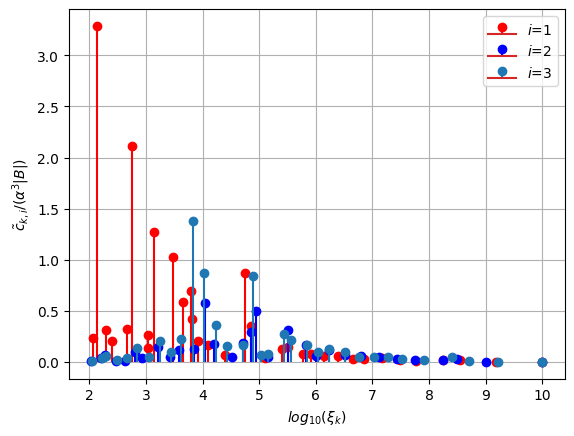

<Figure size 640x480 with 0 Axes>

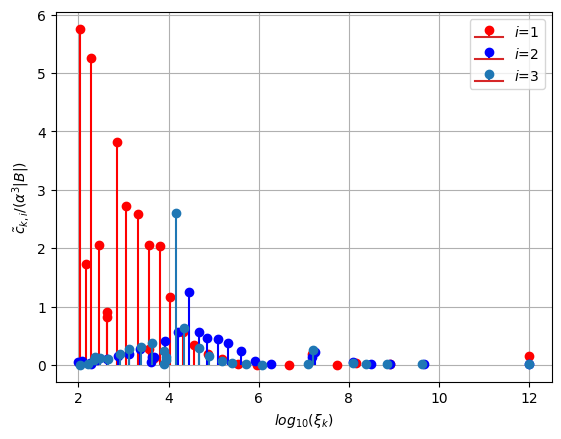

<Figure size 640x480 with 0 Axes>

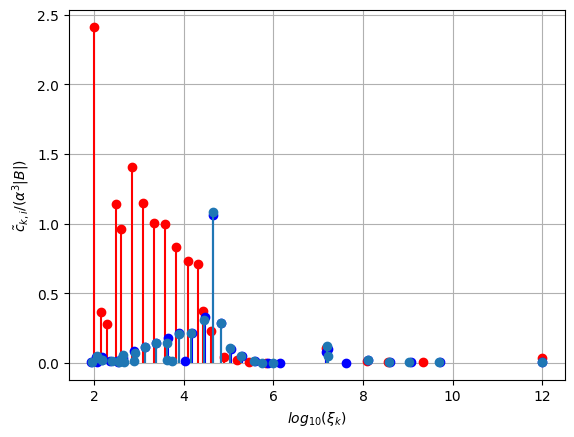

In [477]:
plt.figure()
col=['r','b','x']
plt.figure(1)
for i in range(3):
    nfound=len(xiobj[:,i])
    ckp=ckobj[0:nfound,i]
    xip=xiobj[0:nfound,i]
    plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))
    plt.xlabel(r'$log_{10}(\xi_{k})$')
    plt.ylabel(r'$\tilde{c}_{k,i}/ (\alpha^3 |B| )$')

plt.grid()
#plt.xlim(4,12)
#plt.ylim(0,0.8)
plt.legend()
#plt.savefig("my_plots/sphere_mpt/modes_amp_iter_refine_Nfreq_"+str(N)+"_p_"+str(P)+"_POD_50_1e-6.pdf")

plt.figure()
col=['r','b','x']
plt.figure()
for i in range(3):
    nfound=len(ximinf[:,i])
    ckp=ckminf[0:nfound,i]
    xip=ximinf[0:nfound,i]
    plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))
    plt.xlabel(r'$log_{10}(\xi_{k})$')
    plt.ylabel(r'$\tilde{c}_{k,i}/ (\alpha^3 |B| )$')
    
#print(ckminf)
plt.grid()
#plt.xlim(3,12)
#plt.ylim(0,0.8)

plt.legend()
#plt.savefig("my_plots/sphere_mpt/modes_amp_nnls_Nfreq_"+str(N)+"_p_"+str(P)+"_POD_"+str(NPOD)+"_1e-6.pdf")
#plt.show()
plt.savefig("my_plots/gun/amp_modes_ev3000minf_gun.pdf")

plt.figure()
col=['r','b','x']
plt.figure()
for i in range(3):
    nfound=len(xin0[:,i])
    ckp=ckn0[0:nfound,i]
    xip=xin0[0:nfound,i]
    plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))
    plt.xlabel(r'$log_{10}(\xi_{k})$')
    plt.ylabel(r'$\tilde{c}_{k,i}/ (\alpha^3 |B| )$')
plt.grid()
#plt.xlim(4,12)
#plt.ylim(0,0.8)

plt.savefig("my_plots/gun/amp_modes_ev3000n0_gun.pdf")

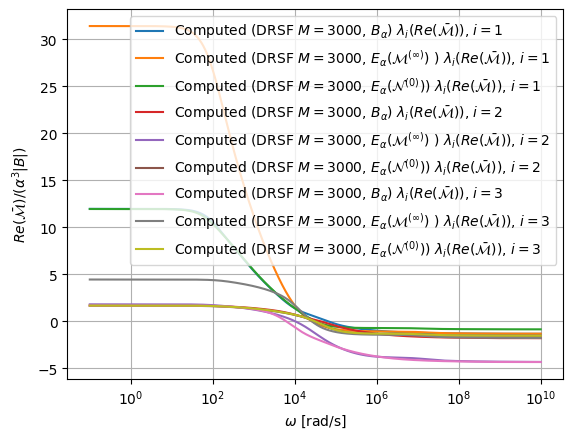

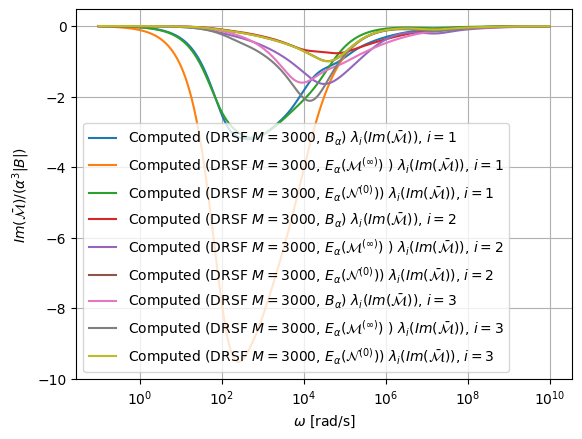

In [480]:
N=len(Omega)
for i in range(3):
    #DRSF=Minftet[i,i]*np.ones((N),dtype=complex)
    nfound=len(xiobj[:,i])
    ckp=ckobj[0:nfound,i]
    xip=xiobj[:,i]
    # We need to use e.values of MPTinf and take account of ordering this is now done in getimpulse_step
    DRSF=(ckp[0])*np.ones((N),dtype=complex)
    for n in range(1,nfound):
        if xip[n] != 0:
            DRSF+=ckp[n]/(1+1j*Omega/xip[n])
    #print(xitet)
    plt.figure(1)
    #plt.semilogx(Omega,np.real(DRSF)/(alpha**3*vol),'x',label=r"Computed (DRSF $M=500$) $\lambda_i({\cal R})$, $i=$"+str(i+1))
    #plt.semilogx(Omega,np.real(Eigenvaluestet[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i({\cal R})$, $i=$"+str(i+1))
    nfound=len(ximinf[:,i])
    ckp=ckminf[0:nfound,i]
    xip=ximinf[:,i]
    # We need to use e.values of MPTinf and take account of ordering this is now done in getimpulse_step
    #DRSFminf=(ckp[0])*np.ones((N),dtype=complex)
    DRSFminf=(ckp[0])*np.ones((N),dtype=complex)
    for n in range(1,nfound):
        if xip[n] != 0:
            DRSFminf+=ckp[n]/(1+1j*Omega/xip[n])

    nfound=len(xin0[:,i])
    ckp=ckn0[0:nfound,i]
    xip=xin0[:,i]
    # We need to use e.values of MPTinf and take account of ordering this is now done in getimpulse_step
    #DRSFn0=Minfn0[i,i]*np.ones((N),dtype=complex)
    DRSFn0=(ckp[0])*np.ones((N),dtype=complex)
    for n in range(1,nfound):
        if xip[n] != 0 :#and xip[n] < 1e10:
            DRSFn0+=ckp[n]/(1+1j*Omega/xip[n])
    
    plt.semilogx(Omega,np.real(DRSF)/(alpha**3*vol),'-',label=r"Computed (DRSF $M=3000$, $B_\alpha$) $\lambda_i(Re(\bar{\cal M}))$, $i=$"+str(i+1))
    plt.semilogx(Omega,np.real(DRSFminf)/(alpha**3*vol),'-',label=r"Computed (DRSF $M=3000$, $E_\alpha({\cal M}^{(\infty)})$ ) $\lambda_i(Re(\bar{\cal M}))$, $i=$"+str(i+1))
    plt.semilogx(Omega,np.real(DRSFn0)/(alpha**3*vol),'-',label=r"Computed (DRSF $M=3000$, $E_\alpha({\cal N}^{(0)})$) $\lambda_i(Re(\bar{\cal M}))$, $i=$"+str(i+1))
    
    #plt.semilogx(Omega,np.real(Eigenvaluesminf[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i(\bar{\cal M})$, $i=$"+str(i+1))
    #plt.semilogx(Omega,np.real(Eigenvaluesn0[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i(\bar{\cal M})$, $i=$"+str(i+1))


    
    plt.figure(2)
    #plt.semilogx(Omega,-np.imag(Eigenvaluestet[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i(\bar{\cal M})$, $i=$"+str(i+1))
    #plt.semilogx(Omega,-np.imag(Eigenvaluesminf[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i(\bar{\cal M})$, $i=$"+str(i+1))
    #plt.semilogx(Omega,-np.imag(Eigenvaluesn0[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i(\bar{\cal M})$, $i=$"+str(i+1))
    #plt.semilogx(Omega,np.imag(DRSFn0)/(alpha**3*vol),label=r"Computed (DRSF $M=500$) $\lambda_i({\cal I})$, $i=$"+str(i+1))
    plt.semilogx(Omega,np.imag(DRSF)/(alpha**3*vol),'-',label=r"Computed (DRSF $M=3000$, $B_\alpha$) $\lambda_i(Im(\bar{\cal M}))$, $i=$"+str(i+1))
    plt.semilogx(Omega,np.imag(DRSFminf)/(alpha**3*vol),'-',label=r"Computed (DRSF $M=3000$, $E_\alpha({\cal M}^{(\infty)})$ ) $\lambda_i(Im(\bar{\cal M}))$, $i=$"+str(i+1))
    plt.semilogx(Omega,np.imag(DRSFn0)/(alpha**3*vol),'-',label=r"Computed (DRSF $M=3000$, $E_\alpha({\cal N}^{(0)})$) $\lambda_i(Im(\bar{\cal M}))$, $i=$"+str(i+1))
               
  
plt.figure(1)

plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"$Re(\bar{\cal M})/(\alpha^3|B|)$")
plt.grid()
plt.legend()
plt.savefig("my_plots/gun/ellip_computed_realmpt_M3000_gun.pdf")


plt.figure(2)
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"$Im(\bar{\cal M})/(\alpha^3|B|)$")
plt.legend()
plt.grid()
plt.savefig("my_plots/gun/ellip_computed_imagmpt_M3000_gun.pdf")
plt.show()

EigResult(eigenvalues=array([0.00372338, 0.00051544, 0.00052134]), eigenvectors=array([[ 9.99992852e-01,  3.78083528e-03,  3.39254672e-05],
       [ 2.81554929e-04, -6.55147123e-02, -9.97851564e-01],
       [ 3.77048978e-03, -9.97844441e-01,  6.55153086e-02]])) EigResult(eigenvalues=array([0.00371252, 0.00051306, 0.00051893]), eigenvectors=array([[ 1.00000000e+00,  1.01721201e-05,  2.03651799e-06],
       [ 2.04102391e-06, -4.42987466e-04, -9.99999902e-01],
       [ 1.01712170e-05, -9.99999902e-01,  4.42987486e-04]]))
[0.03495979 0.00766377 0.00776551]


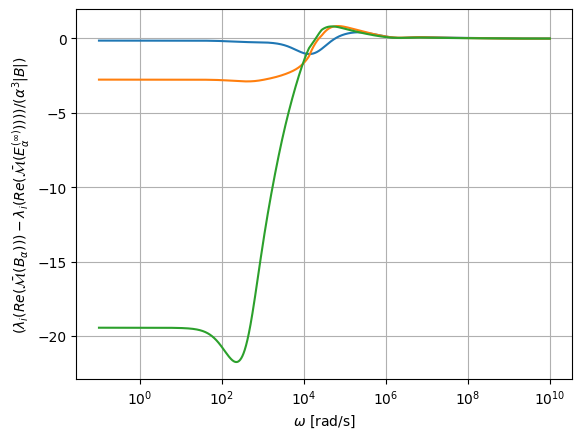

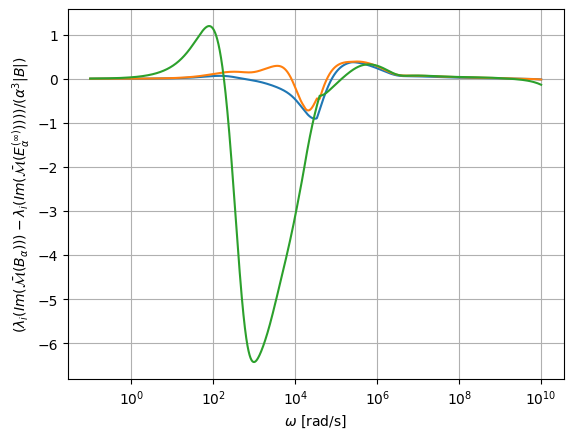

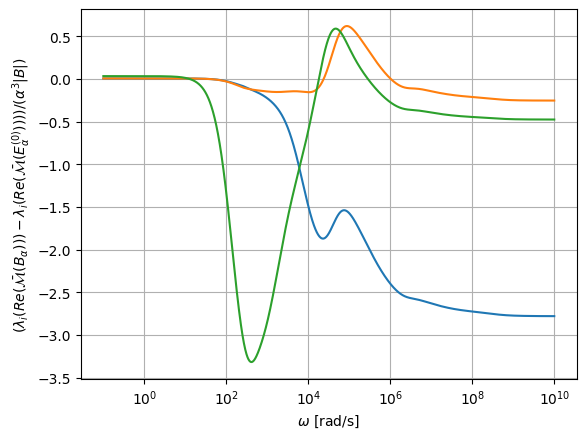

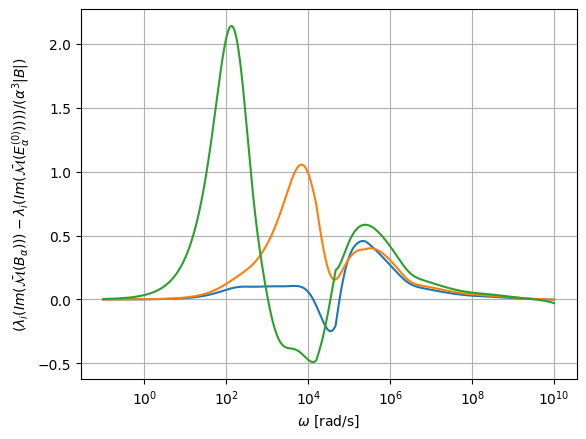

In [481]:

# Compute eigenvalues based on Q
for n in range(N):
    
    MPT=np.zeros((3,3),dtype=complex)
    MPT[0,0]=TensorArrayobj[n,0]
    MPT[0,1]=TensorArrayobj[n,1]
    MPT[0,2]=TensorArrayobj[n,2]
    MPT[1,0]=TensorArrayobj[n,3]
    MPT[1,1]=TensorArrayobj[n,4]
    MPT[1,2]=TensorArrayobj[n,5]
    MPT[2,0]=TensorArrayobj[n,6]
    MPT[2,1]=TensorArrayobj[n,7]
    MPT[2,2]=TensorArrayobj[n,8]
    reig,dum=np.linalg.eig(np.real(MPT))
    reig=np.sort(reig)
    ieig,dum=np.linalg.eig(np.imag(MPT))
    ieig=np.sort(ieig)
    
    Eigenvaluesobj[n,:]=reig+1j*ieig
    MPT[0,0]=TensorArrayminf[n,0]
    MPT[0,1]=TensorArrayminf[n,1]
    MPT[0,2]=TensorArrayminf[n,2]
    MPT[1,0]=TensorArrayminf[n,3]
    MPT[1,1]=TensorArrayminf[n,4]
    MPT[1,2]=TensorArrayminf[n,5]
    MPT[2,0]=TensorArrayminf[n,6]
    MPT[2,1]=TensorArrayminf[n,7]
    MPT[2,2]=TensorArrayminf[n,8]
    reig,dum=np.linalg.eig(np.real(MPT))
    reig=np.sort(reig)
    ieig,dum=np.linalg.eig(np.imag(MPT))
    ieig=np.sort(ieig)
    Eigenvaluesminf[n,:]=reig+1j*ieig
for i in range(3):    
    plt.figure(1)
    #plt.semilogx(Omega,np.real(DRSF)/(alpha**3*vol),'x',label=r"Computed (DRSF $M=500$) $\lambda_i({\cal R})$, $i=$"+str(i+1))
    plt.semilogx(Omega,np.real(Eigenvaluesobj[:,i])/(alpha**3*vol)-np.real(Eigenvaluesminf[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i({\cal R})$, $i=$"+str(i+1))

    
   
    plt.figure(2)
    plt.semilogx(Omega,np.imag(Eigenvaluesobj[:,i])/(alpha**3*vol)-np.imag(Eigenvaluesminf[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i({\cal R})$, $i=$"+str(i+1))

plt.figure(1)
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"$(\lambda_i ( Re(\bar{\cal M} (B_\alpha )) )- \lambda_i (Re(\bar{\cal M} ( E_\alpha^{( \infty) } ) )) ) /(\alpha^3 |B|)$")
plt.grid()
plt.savefig("my_plots/gun/ellip_inf_gun_diff_realmpt_M3000.pdf")


plt.figure(2)
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"$(\lambda_i ( Im(\bar{\cal M} (B_\alpha )) )- \lambda_i (Im(\bar{\cal M} ( E_\alpha^{( \infty) } ) ) )) /(\alpha^3 |B|)$")
plt.grid()
plt.savefig("my_plots/gun/ellip_inf_gun_diff_imagmpt_M3000.pdf")


for n in range(N):
    
    MPT=np.zeros((3,3),dtype=complex)
    MPT[0,0]=TensorArrayobj[n,0]
    MPT[0,1]=TensorArrayobj[n,1]
    MPT[0,2]=TensorArrayobj[n,2]
    MPT[1,0]=TensorArrayobj[n,3]
    MPT[1,1]=TensorArrayobj[n,4]
    MPT[1,2]=TensorArrayobj[n,5]
    MPT[2,0]=TensorArrayobj[n,6]
    MPT[2,1]=TensorArrayobj[n,7]
    MPT[2,2]=TensorArrayobj[n,8]
    reig,dum=np.linalg.eig(np.real(MPT))
    reig=np.sort(reig)
    ieig,dum=np.linalg.eig(np.imag(MPT))
    ieig=np.sort(ieig)
    
    Eigenvaluesobj[n,:]=reig+1j*ieig
    MPT[0,0]=TensorArrayn0[n,0]
    MPT[0,1]=TensorArrayn0[n,1]
    MPT[0,2]=TensorArrayn0[n,2]
    MPT[1,0]=TensorArrayn0[n,3]
    MPT[1,1]=TensorArrayn0[n,4]
    MPT[1,2]=TensorArrayn0[n,5]
    MPT[2,0]=TensorArrayn0[n,6]
    MPT[2,1]=TensorArrayn0[n,7]
    MPT[2,2]=TensorArrayn0[n,8]
    reig,dum=np.linalg.eig(np.real(MPT))
    reig=np.sort(reig)
    ieig,dum=np.linalg.eig(np.imag(MPT))
    ieig=np.sort(ieig)
    Eigenvaluesn0[n,:]=reig+1j*ieig
for i in range(3):    
    plt.figure(3)
    #plt.semilogx(Omega,np.real(DRSF)/(alpha**3*vol),'x',label=r"Computed (DRSF $M=500$) $\lambda_i({\cal R})$, $i=$"+str(i+1))
    plt.semilogx(Omega,np.real(Eigenvaluesobj[:,i])/(alpha**3*vol)-np.real(Eigenvaluesn0[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i({\cal R})$, $i=$"+str(i+1))

    
   
    plt.figure(4)
    plt.semilogx(Omega,np.imag(Eigenvaluesobj[:,i])/(alpha**3*vol)-np.imag(Eigenvaluesn0[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i({\cal R})$, $i=$"+str(i+1))



plt.figure(3)
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"$(\lambda_i ( Re(\bar{\cal M} (B_\alpha )) )- \lambda_i (Re(\bar{\cal M} ( E_\alpha^{( 0) } ) )) ) /(\alpha^3 |B|)$")
plt.grid()
plt.savefig("my_plots/gun/ellip_n0_gun_diff_realmpt_M3000.pdf")



plt.figure(4)
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"$(\lambda_i ( Im(\bar{\cal M} (B_\alpha )) )- \lambda_i (Im(\bar{\cal M} ( E_\alpha^{( 0) } ) ) )) /(\alpha^3 |B|)$")
plt.grid()
plt.savefig("my_plots/gun/ellip_n0_gun_diff_imagmpt_M3000.pdf")

n0obju,dum=np.linalg.eig(N0obj)
n0n0u,dum=np.linalg.eig(N0n0)
print(np.linalg.eig(N0obj),np.linalg.eig(N0n0))
print((n0obju-n0n0u)/(alpha**3*vol))

#print(np.real(Eigenvaluestet[:,0])/(alpha**3*vol)-np.real(Eigenvaluesn0[:,0])/(alpha**3*vol))